In [4]:
pip install streamlit pandas numpy scikit-learn matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/forest-fires/forestfires.csv"
df = pd.read_csv(url)

In [ ]:
display(df.head())

df.info()

display(df.describe())

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


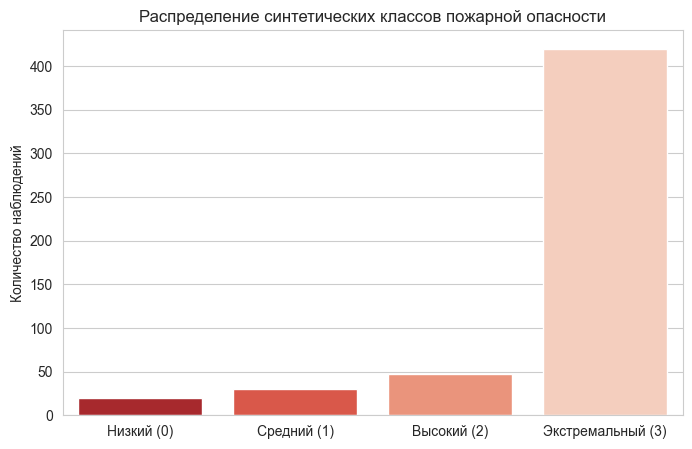

danger_class
0     20
1     30
2     47
3    420
Name: count, dtype: int64


In [11]:
def get_danger_class(row):
    score = 0
    if row['FFMC'] > 85: score += 1  
    if row['DMC'] > 40: score += 1  
    if row['DC'] > 300: score += 1   
    if row['ISI'] > 10: score += 1   
    if row['temp'] > 25: score += 1  
    if row['RH'] < 40: score += 1    
    
    return min(score, 3)

df['danger_class'] = df.apply(get_danger_class, axis=1)


class_names = ['Низкий (0)', 'Средний (1)', 'Высокий (2)', 'Экстремальный (3)']
class_counts = df['danger_class'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts.values, palette='Reds_r')
plt.title('Распределение синтетических классов пожарной опасности')
plt.ylabel('Количество наблюдений')
plt.show()

print(class_counts)

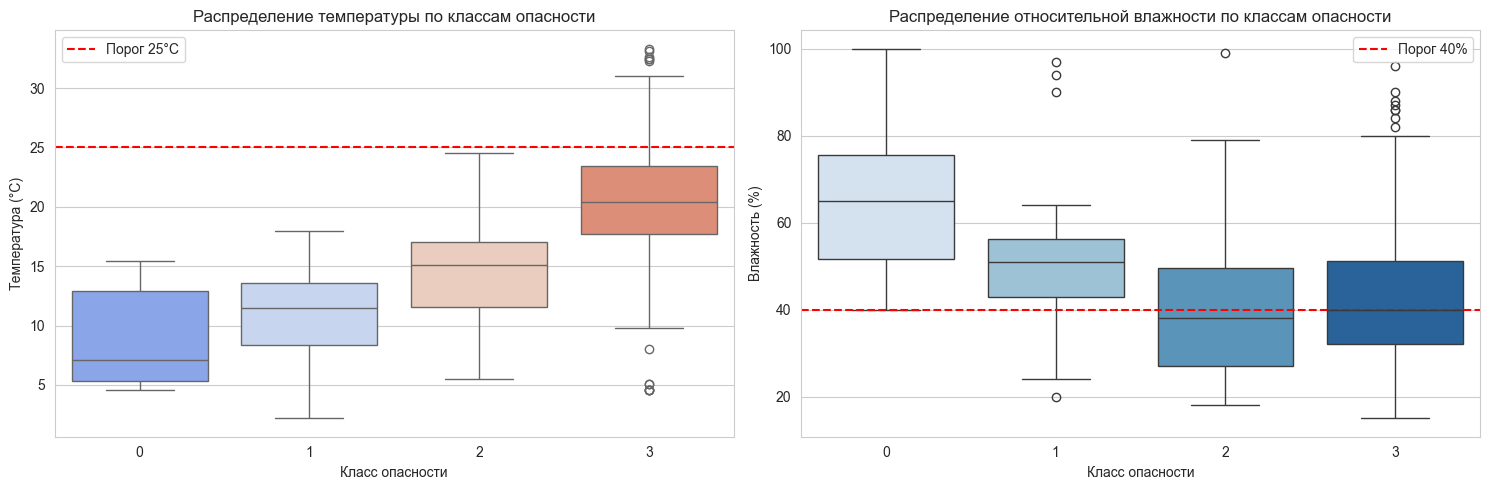

Вывод по аналитике:
При температуре > 25°C и влажности < 40% класс опасности стабильно переходит в зоны Высокого (2) и Экстремального (3) риска.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='danger_class', y='temp', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Распределение температуры по классам опасности')
axes[0].set_xlabel('Класс опасности')
axes[0].set_ylabel('Температура (°C)')
axes[0].axhline(y=25, color='r', linestyle='--', label='Порог 25°C')
axes[0].legend()

sns.boxplot(x='danger_class', y='RH', data=df, ax=axes[1], palette='Blues')
axes[1].set_title('Распределение относительной влажности по классам опасности')
axes[1].set_xlabel('Класс опасности')
axes[1].set_ylabel('Влажность (%)')
axes[1].axhline(y=40, color='r', linestyle='--', label='Порог 40%')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
le_month = LabelEncoder()
le_day = LabelEncoder()
df['month_enc'] = le_month.fit_transform(df['month'])
df['day_enc'] = le_day.fit_transform(df['day'])

features = ['month_enc', 'day_enc', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
X = df[features]
y = df['danger_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (413, 10)
Размер тестовой выборки: (104, 10)


In [15]:
print("Обучение модели Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели (Accuracy): {accuracy:.4f}")

print("\nОтчет о классификации:")
class_names_report = ['Низкий', 'Средний', 'Высокий', 'Экстремальный']
print(classification_report(y_test, y_pred, target_names=class_names_report))

Обучение модели Random Forest...
Точность модели (Accuracy): 0.9327

Отчет о классификации:
               precision    recall  f1-score   support

       Низкий       0.80      1.00      0.89         4
      Средний       1.00      0.50      0.67         6
      Высокий       0.64      0.78      0.70         9
Экстремальный       0.98      0.98      0.98        85

     accuracy                           0.93       104
    macro avg       0.85      0.81      0.81       104
 weighted avg       0.94      0.93      0.93       104



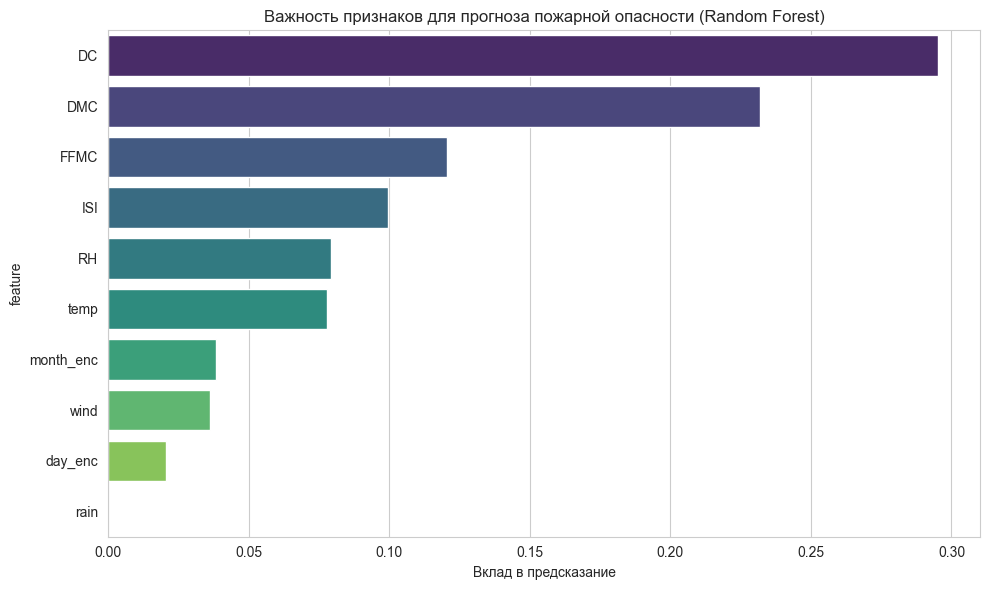

Топ-5 факторов, влияющих на пожарную опасность:


,feature,importance
4,DC,0.295383
3,DMC,0.232023
2,FFMC,0.120404
5,ISI,0.099623
7,RH,0.079472


In [16]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Важность признаков для прогноза пожарной опасности (Random Forest)')
plt.xlabel('Вклад в предсказание')
plt.tight_layout()
plt.show()

print("Топ-5 факторов, влияющих на пожарную опасность:")
display(feature_importance.head(5))

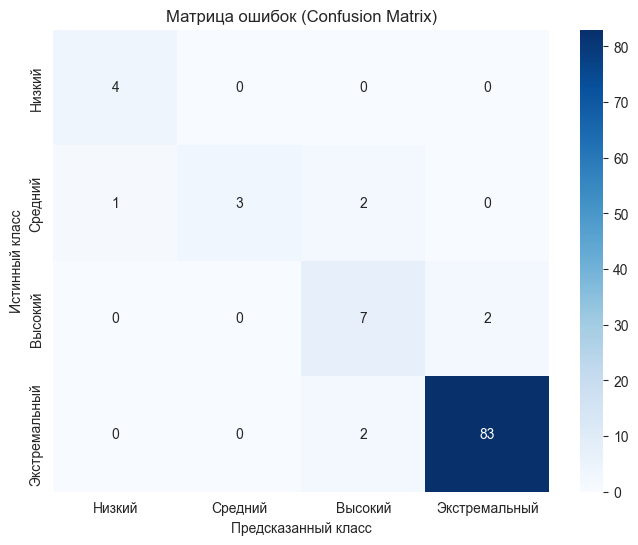

Интерпретация ошибок:
- False Positive (вне диагонали вправо): Ложная тревога.
- False Negative (вне диагонали вниз): Пропуск опасной ситуации (критично для МЧС!).


In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=class_names_report, 
            yticklabels=class_names_report)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("Интерпретация ошибок:")
print("- False Positive (вне диагонали вправо): Ложная тревога.")
print("- False Negative (вне диагонали вниз): Пропуск опасной ситуации (критично для МЧС!).")

In [18]:
joblib.dump(model, 'fire_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump({'month': le_month, 'day': le_day}, 'encoders.pkl')

print("Модель и энкодеры сохранены в файлы:")
print("- fire_model.pkl")
print("- scaler.pkl")
print("- encoders.pkl")

Модель и энкодеры сохранены в файлы:
- fire_model.pkl
- scaler.pkl
- encoders.pkl


In [19]:
def predict_fire_danger(month, day, FFMC, DMC, DC, ISI, temp, RH, wind, rain):

    model_loaded = joblib.load('fire_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    encoders_loaded = joblib.load('encoders.pkl')
    
    try:
        month_enc = encoders_loaded['month'].transform([month])[0]
        day_enc = encoders_loaded['day'].transform([day])[0]
    except ValueError:
        month_enc, day_enc = -1, -1
        
    input_data = np.array([[month_enc, day_enc, FFMC, DMC, DC, ISI, temp, RH, wind, rain]])
    input_scaled = scaler_loaded.transform(input_data)
    
    pred_class = model_loaded.predict(input_scaled)[0]
    proba = model_loaded.predict_proba(input_scaled)[0]
    
    class_dict = {0: "Низкий", 1: "Средний", 2: "Высокий", 3: "Экстремальный"}
    
    return class_dict[pred_class], proba[pred_class]

test_class, test_conf = predict_fire_danger(
    month='aug', day='sun', 
    FFMC=92.0, DMC=120.0, DC=700.0, ISI=15.0, 
    temp=32.0, RH=25.0, wind=4.0, rain=0.0
)

print("Тест функции прогноза:")
print(f"Входные параметры: Жаркий сухой день (Август)")
print(f"Результат: Класс '{test_class}' с уверенностью {test_conf*100:.1f}%")

Тест функции прогноза:
Входные параметры: Жаркий сухой день (Август)
Результат: Класс 'Экстремальный' с уверенностью 100.0%
